In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import joblib
import gradio as gr

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

In [3]:
df = pd.read_csv(
    "bank-additional-full.csv",
    sep=";"
)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

display(df.head())

Dataset loaded successfully!
Shape: (41188, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [4]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn Names:")
print(df.columns.tolist())

Number of rows: 41188
Number of columns: 21

Column Names:
['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y']


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null  float64
 1

In [6]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [7]:
df.describe(include="object")

,job,marital,education,default,housing,loan,contact,month,day_of_week,poutcome,y
count,41188,41188,41188,41188,41188,41188,41188,41188,41188,41188,41188
unique,12,4,8,3,3,3,2,10,5,3,2
top,admin.,married,university.degree,no,yes,no,cellular,may,thu,nonexistent,no
freq,10422,24928,12168,32588,21576,33950,26144,13769,8623,35563,36548


In [8]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64


In [9]:
unknown_summary = {}

for col in df.select_dtypes(include="object").columns:
    unknown_summary[col] = (df[col] == "unknown").sum()

unknown_df = pd.DataFrame(
    unknown_summary.items(),
    columns=["Column", "Unknown_Count"]
)

unknown_df = unknown_df.sort_values(
    by="Unknown_Count",
    ascending=False
)

display(unknown_df)

,Column,Unknown_Count
3,default,8597
2,education,1731
4,housing,990
5,loan,990
0,job,330
1,marital,80
6,contact,0
7,month,0
8,day_of_week,0
9,poutcome,0


In [10]:
print(
    "Number of duplicate rows:",
    df.duplicated().sum()
)

Number of duplicate rows: 12


In [11]:
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (41176, 21)


In [12]:
print(
    df["y"].value_counts(normalize=True) * 100
)

y
no     88.733728
yes    11.266272
Name: proportion, dtype: float64


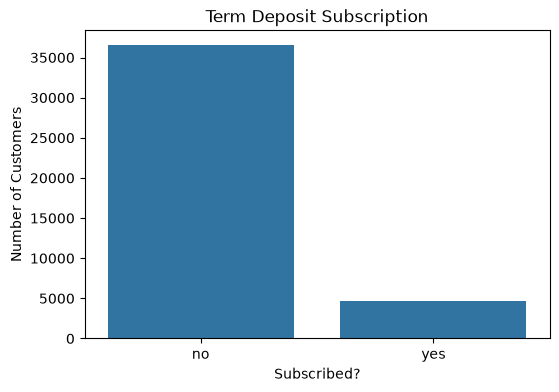

In [13]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x="y"
)

plt.title("Term Deposit Subscription")
plt.xlabel("Subscribed?")
plt.ylabel("Number of Customers")

plt.show()

In [14]:
numerical_columns = df.select_dtypes(
    include=np.number
).columns.tolist()

print("Numerical columns:")
print(numerical_columns)

Numerical columns:
['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']


In [15]:
categorical_columns = df.select_dtypes(
    include="object"
).columns.tolist()

print("Categorical columns:")
print(categorical_columns)

Categorical columns:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome', 'y']


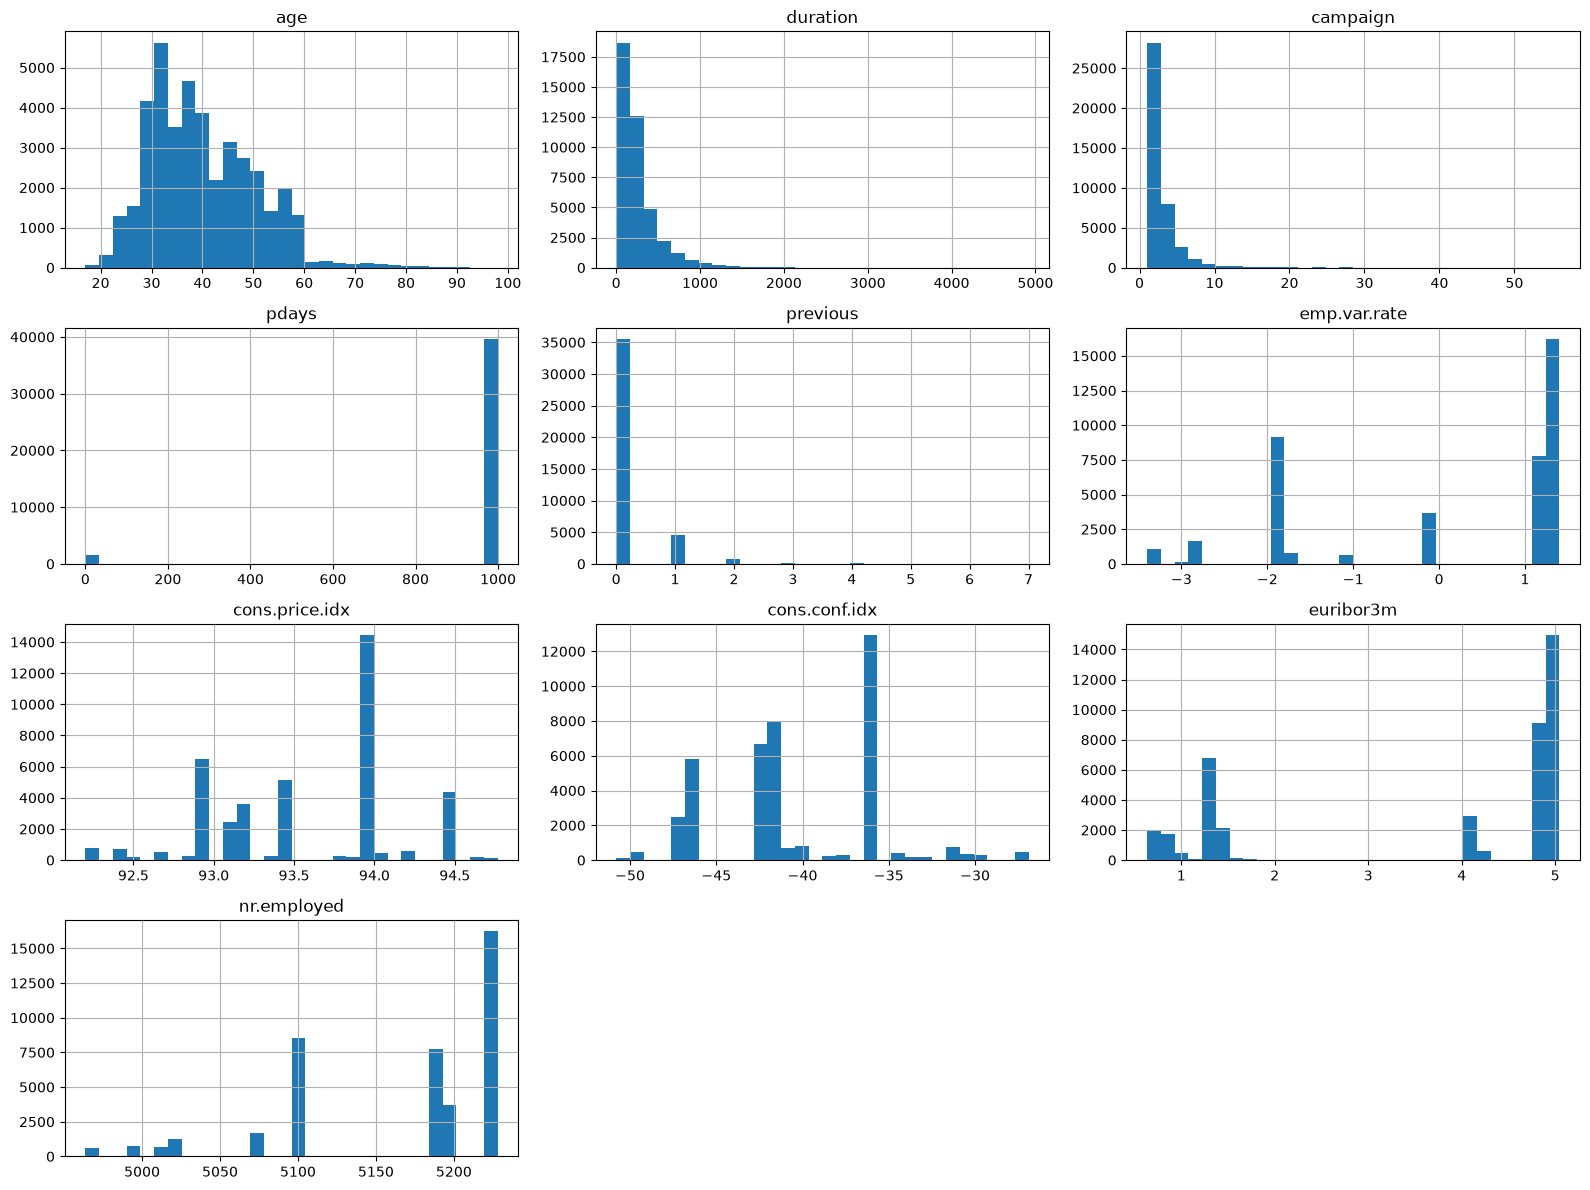

In [16]:
df[numerical_columns].hist(
    figsize=(16, 12),
    bins=30
)

plt.tight_layout()
plt.show()

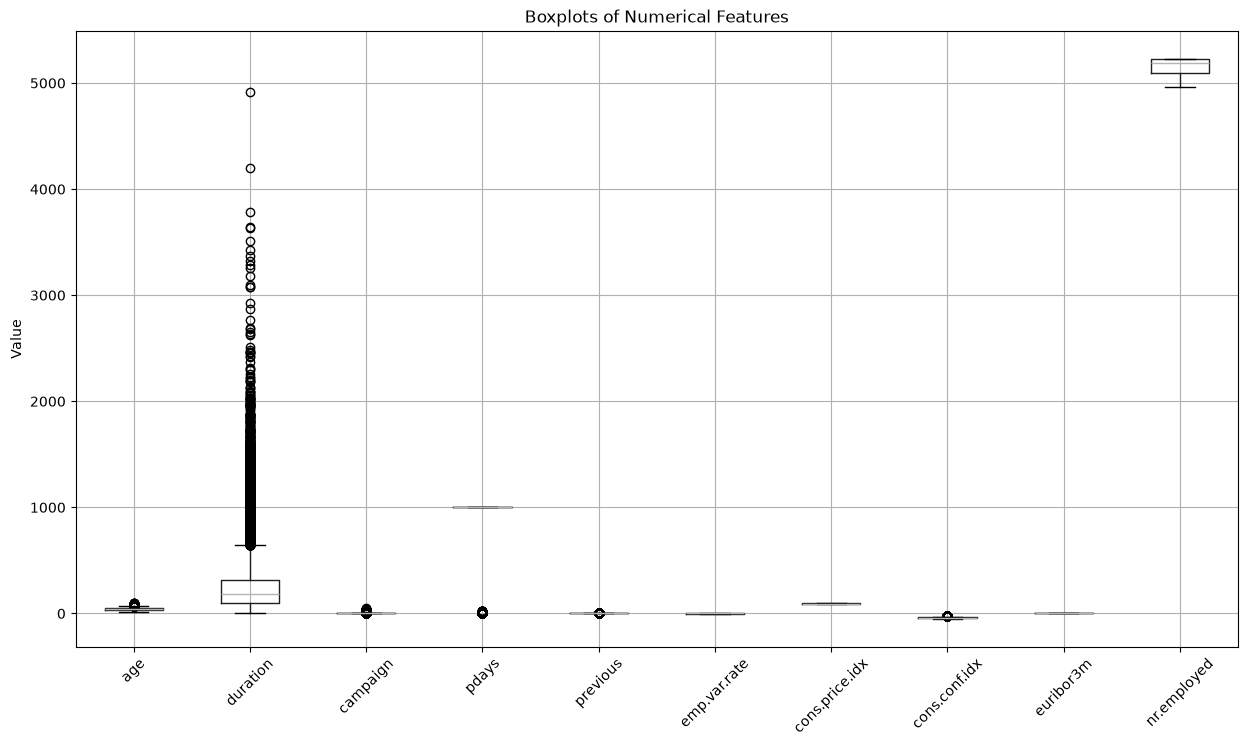

In [17]:
plt.figure(figsize=(15, 8))

df[numerical_columns].boxplot()

plt.xticks(rotation=45)
plt.title("Boxplots of Numerical Features")
plt.ylabel("Value")

plt.show()

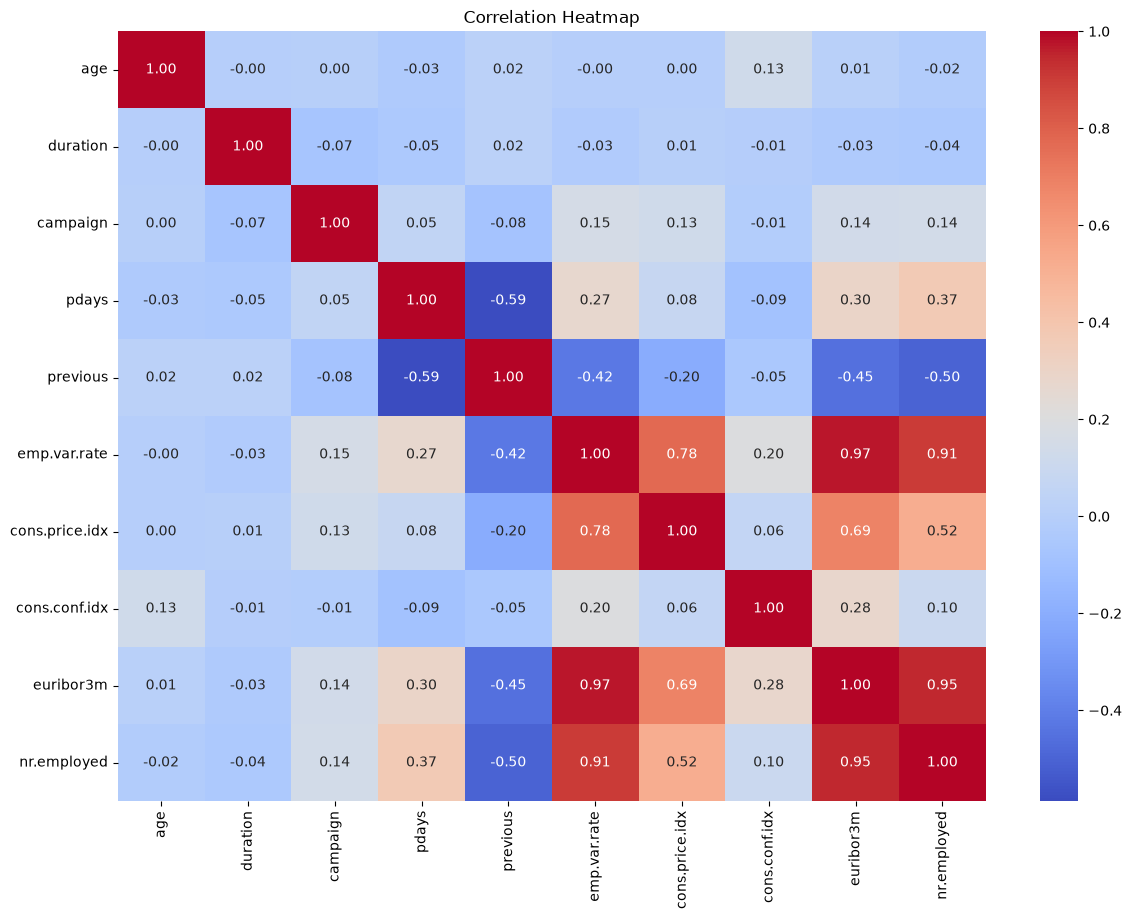

In [18]:
plt.figure(figsize=(14, 10))

correlation = df[numerical_columns].corr()

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

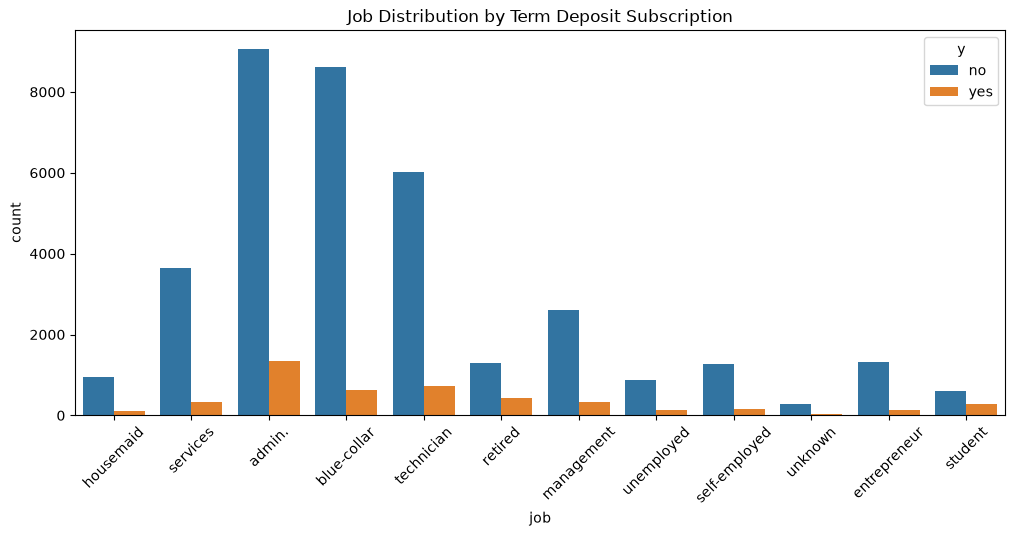

In [19]:
plt.figure(figsize=(12, 5))

sns.countplot(
    data=df,
    x="job",
    hue="y"
)

plt.xticks(rotation=45)

plt.title(
    "Job Distribution by Term Deposit Subscription"
)

plt.show()

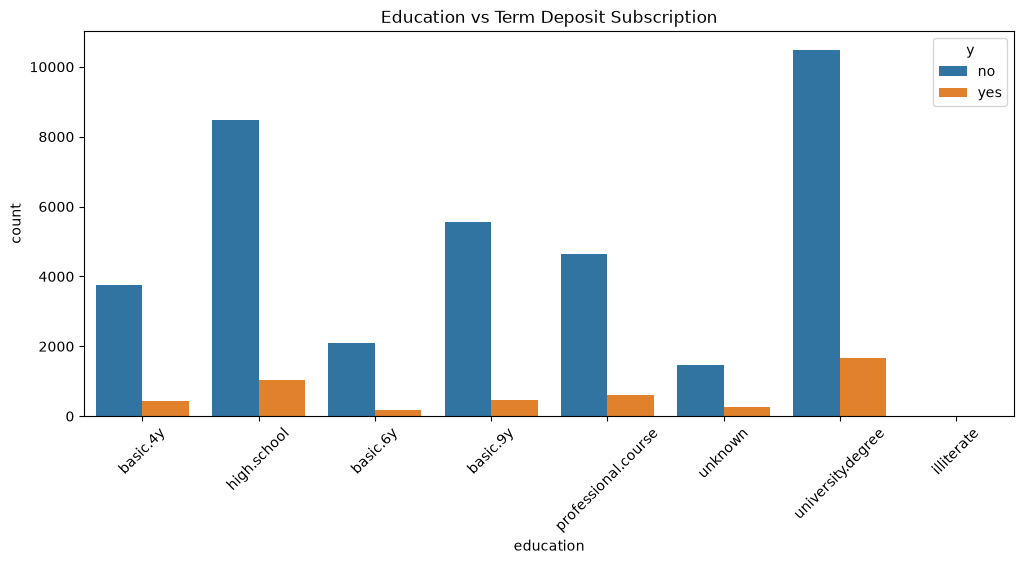

In [20]:
plt.figure(figsize=(12, 5))

sns.countplot(
    data=df,
    x="education",
    hue="y"
)

plt.xticks(rotation=45)

plt.title(
    "Education vs Term Deposit Subscription"
)

plt.show()

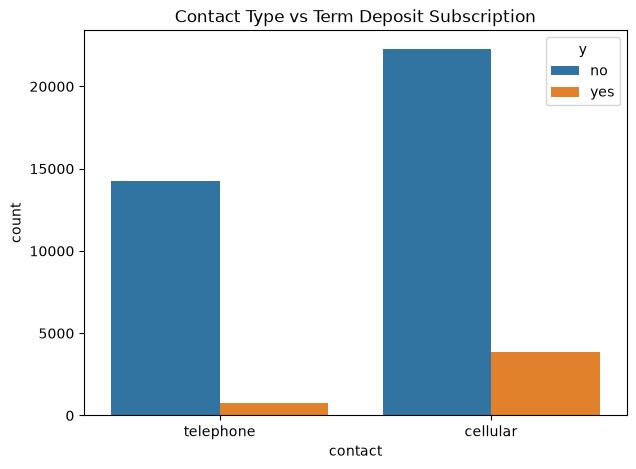

In [21]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="contact",
    hue="y"
)

plt.title(
    "Contact Type vs Term Deposit Subscription"
)

plt.show()

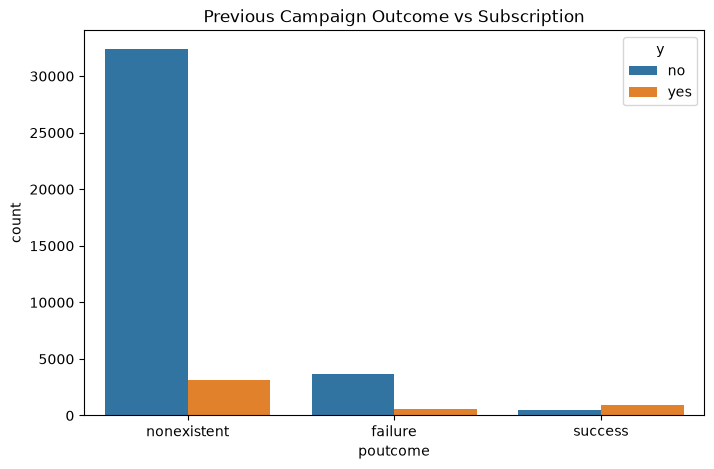

In [22]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="poutcome",
    hue="y"
)

plt.title(
    "Previous Campaign Outcome vs Subscription"
)

plt.show()

In [23]:
df["previously_contacted"] = (
    df["pdays"] != 999
).astype(int)

In [24]:
df["multiple_contacts"] = (
    df["campaign"] > 1
).astype(int)

In [25]:
df["age_group"] = pd.cut(
    df["age"],
    bins=[0, 25, 35, 50, 65, 100],
    labels=[
        "Young",
        "Adult",
        "Middle_Aged",
        "Senior",
        "Elderly"
    ]
)

In [26]:
print(df["age_group"].value_counts())

age_group
Middle_Aged    17489
Adult          14844
Senior          6560
Young           1665
Elderly          618
Name: count, dtype: int64


In [27]:
df["previous_success"] = (
    df["poutcome"] == "success"
).astype(int)

In [28]:
display(
    df[
        [
            "age",
            "age_group",
            "pdays",
            "previously_contacted",
            "campaign",
            "multiple_contacts",
            "poutcome",
            "previous_success"
        ]
    ].head(10)
)

,age,age_group,pdays,previously_contacted,campaign,multiple_contacts,poutcome,previous_success
0,56,Senior,999,0,1,0,nonexistent,0
1,57,Senior,999,0,1,0,nonexistent,0
2,37,Middle_Aged,999,0,1,0,nonexistent,0
3,40,Middle_Aged,999,0,1,0,nonexistent,0
4,56,Senior,999,0,1,0,nonexistent,0
5,45,Middle_Aged,999,0,1,0,nonexistent,0
6,59,Senior,999,0,1,0,nonexistent,0
7,41,Middle_Aged,999,0,1,0,nonexistent,0
8,24,Young,999,0,1,0,nonexistent,0
9,25,Young,999,0,1,0,nonexistent,0


In [29]:
df = df.drop(
    "duration",
    axis=1
)

print("duration removed.")

duration removed.


In [30]:
X = df.drop(
    "y",
    axis=1
)

y = df["y"].map({
    "no": 0,
    "yes": 1
})

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (41176, 23)
y shape: (41176,)


In [35]:
# Find all categorical columns
categorical_columns = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Categorical columns:")
print(categorical_columns)

Categorical columns:
['age_group']


In [37]:
X = pd.get_dummies(
    X,
    columns=categorical_columns,
    drop_first=True
)

print("Shape after encoding:", X.shape)
print("Remaining non-numeric columns:")

print(
    X.select_dtypes(
        include=["object", "category"]
    ).columns.tolist()
)

Shape after encoding: (41176, 59)
Remaining non-numeric columns:
[]


In [38]:
X = X.astype(float)

print("All features are now numeric!")
print(X.dtypes.value_counts())

All features are now numeric!
float64    59
Name: count, dtype: int64


In [39]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training shape: (32940, 59)
Testing shape: (8236, 59)


In [40]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

print("Feature scaling completed!")

Feature scaling completed!


In [41]:
model = Sequential()

model.add(
    Dense(
        64,
        activation="relu",
        input_shape=(X_train_scaled.shape[1],)
    )
)

model.add(
    Dropout(0.3)
)

model.add(
    Dense(
        32,
        activation="relu"
    )
)

model.add(
    Dropout(0.2)
)

model.add(
    Dense(
        16,
        activation="relu"
    )
)

model.add(
    Dense(
        1,
        activation="sigmoid"
    )
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         3,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,465 (25.25 KB)

 Trainable params: 6,465 (25.25 KB)

 Non-trainable params: 0 (0.00 B)

In [42]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [43]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [44]:
history = model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.20,
    epochs=50,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/50
824/824 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8916 - loss: 0.3135 - val_accuracy: 0.8945 - val_loss: 0.2911
Epoch 2/50
824/824 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8976 - loss: 0.2862 - val_accuracy: 0.8928 - val_loss: 0.2908
Epoch 3/50
824/824 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8975 - loss: 0.2813 - val_accuracy: 0.8947 - val_loss: 0.2901
Epoch 4/50
824/824 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8978 - loss: 0.2808 - val_accuracy: 0.8954 - val_loss: 0.2885
Epoch 5/50
824/824 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8988 - loss: 0.2776 - val_accuracy: 0.8956 - val_loss: 0.2889
Epoch 6/50
824/824 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9002 - loss: 0.2765 - val_accuracy: 0.8954 - val_loss: 0.2894
Epoch 7/50
824/824 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9007 - loss: 0.2743 - val_accuracy: 0.8963 - val_loss: 0.2893
Epoch 8/50
824/824 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9022 - loss: 0.2730 - val_accuracy: 0.

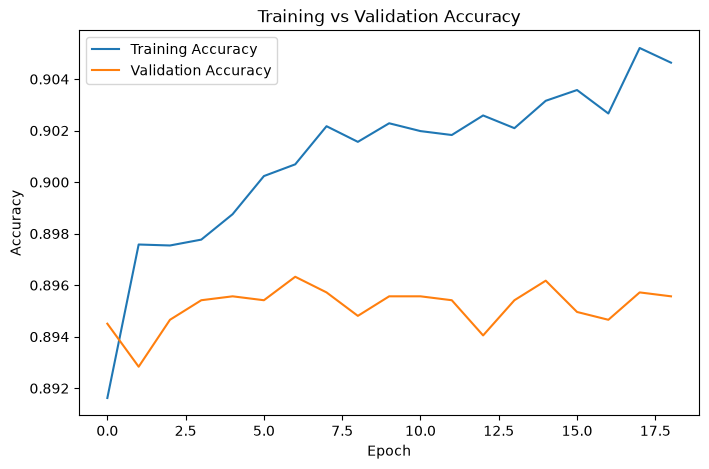

In [45]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title(
    "Training vs Validation Accuracy"
)

plt.legend()

plt.show()

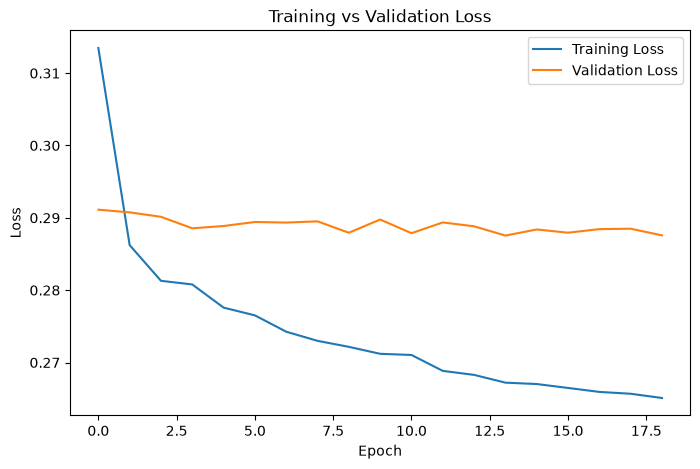

In [46]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "Training vs Validation Loss"
)

plt.legend()

plt.show()

In [48]:
test_loss, test_accuracy = model.evaluate(
    X_test_scaled,
    y_test,
    verbose=0
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

Test Loss: 0.27352121472358704
Test Accuracy: 0.8997085690498352


In [49]:
y_probability = model.predict(
    X_test_scaled
)

y_pred = (
    y_probability >= 0.5
).astype(int)

258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [50]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.8997085964060223
Precision: 0.6574074074074074
Recall   : 0.22952586206896552
F1 Score : 0.3402555910543131


In [51]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "No Subscription",
            "Subscription"
        ]
    )
)

                 precision    recall  f1-score   support

No Subscription       0.91      0.98      0.95      7308
   Subscription       0.66      0.23      0.34       928

       accuracy                           0.90      8236
      macro avg       0.78      0.61      0.64      8236
   weighted avg       0.88      0.90      0.88      8236



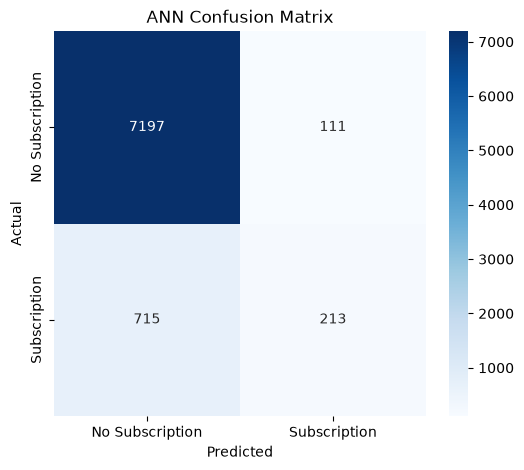

In [52]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "No Subscription",
        "Subscription"
    ],
    yticklabels=[
        "No Subscription",
        "Subscription"
    ]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("ANN Confusion Matrix")

plt.show()

In [53]:
roc_auc = roc_auc_score(
    y_test,
    y_probability
)

print("ROC-AUC:", roc_auc)

ROC-AUC: 0.7994038182058396


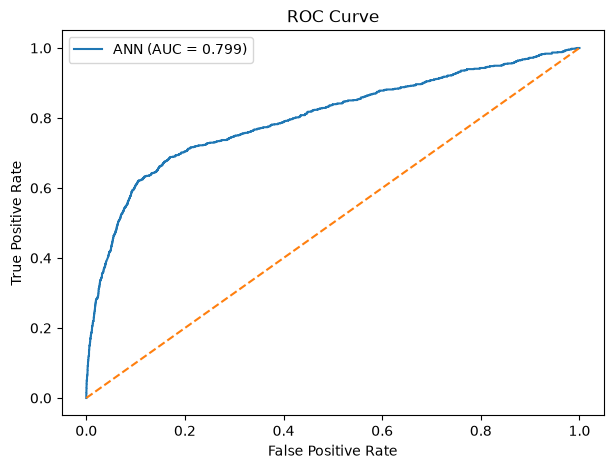

In [54]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_probability
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"ANN (AUC = {roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

In [55]:
results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    
    "Score": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ]
})

display(results)

,Metric,Score
0,Accuracy,0.899709
1,Precision,0.657407
2,Recall,0.229526
3,F1 Score,0.340256
4,ROC-AUC,0.799404


In [56]:
model.save(
    "bank_marketing_ann.keras"
)

joblib.dump(
    scaler,
    "bank_marketing_scaler.pkl"
)

joblib.dump(
    X.columns.tolist(),
    "bank_marketing_features.pkl"
)

print("Model, scaler and feature information saved!")

Model, scaler and feature information saved!


In [67]:
!python -m pip install joblib

In [69]:
!pip install joblib

In [70]:
import joblib
print(joblib.__version__)

1.6.0
